# TVR Benchmark Analysis CLIP4Clip & GRAM


**Pipeline for each model:**
1. Load the test/train similarity matrix produced by the evaluation script
0. Validate on the train split to calibrate per-query thresholds 
2. Apply per-query min-max normalisation (same as in validation)
3. Apply the per-query threshold calibrated on the train split
4. Compute **F1 (macro-avg)**, **mIoU**, and **mAP** per query → aggregate

| Symbol | Meaning |
|---|---|
| mIoU | mean Intersection-over-Union (predicted set ∩ GT) / (predicted set ∪ GT), averaged across queries |
| F1 (macro-avg) | unweighted mean of per-query binary F1 |
| mAP | mean Average Precision area under the per-query precision–recall curve |

## 1. Import Libraries and Configure Paths

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from metrics import (
    mean_average_precision_score,
    F1_score_from_sim,
    IoU_from_sim,
    IoU_q
)

%load_ext autoreload
%autoreload 2
base_path="../zero_shot"

# CLIP4Clip
clip_path = Path(base_path) / "CLIP4Clip"
CLIP_SIM_TEST   = clip_path / "eval_dataset_clip_empty_queries/test/similarity_matrix.csv"
CLIP_SIM_TRAIN  = clip_path / "eval_dataset_clip_empty_queries/train/similarity_matrix.csv"
CLIP_GT_TEST    = clip_path / "dataset/test/ground_truth.json"
CLIP_GT_TRAIN   = clip_path / "dataset/train/ground_truth.json"
# SIGLIP
siglip_path = Path(base_path) / "SIGLIP"
SIGLIP_SIM_TEST   = siglip_path / "eval_dataset_siglip_empty_queries/test/similarity_matrix.csv"
SIGLIP_SIM_TRAIN  = siglip_path / "eval_dataset_siglip_empty_queries/train/similarity_matrix.csv"
SIGLIP_GT_TEST    = siglip_path / "dataset/test/ground_truth.json"
SIGLIP_GT_TRAIN   = siglip_path / "dataset/train/ground_truth.json"
# GRAM
gram_path = Path(base_path) / "GRAM"
GRAM_SIM_TEST   = "/media/eceo_scratch_haas001/prompting-mammalps-dev/zero_shot/GRAM/eval_results_empty_queries/test/similarity_matrix.csv"
GRAM_GT_TEST    = gram_path / "dataset/test/ground_truth.json"
GRAM_SIM_TRAIN  = "/media/eceo_scratch_haas001/prompting-mammalps-dev/zero_shot/GRAM/eval_results/train/similarity_matrix.csv"
GRAM_GT_TRAIN   = gram_path / "dataset/train/ground_truth.json"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Similarity Matrices

In [ ]:
# Load raw similarity matrices  shape: (n_videos, n_queries), index = video_id
clip_sim__test_df = pd.read_csv(CLIP_SIM_TEST, index_col="video_id")
gram_sim_test_df = pd.read_csv(GRAM_SIM_TEST, index_col="video_id")
siglip_sim_test_df = pd.read_csv(SIGLIP_SIM_TEST, index_col="video_id")
clip_sim_train_df = pd.read_csv(CLIP_SIM_TRAIN, index_col="video_id")
gram_sim_train_df = pd.read_csv(GRAM_SIM_TRAIN, index_col="video_id")
siglip_sim_train_df = pd.read_csv(SIGLIP_SIM_TRAIN, index_col="video_id")

## Load Ground Truth and Per-Query Thresholds

In [1]:
# Ground truth: {query_text: {"videos": [video_id, ...], "category": "RARE"|"COMMON"}}
with open(CLIP_GT_TEST) as f:
    clip_gt = json.load(f)
with open(GRAM_GT_TEST) as f:
    gram_gt = json.load(f)

print(f"CLIP4Clip GT queries : {len(clip_gt)}")
print(f"GRAM GT queries      : {len(gram_gt)}")
print(f"Category values      : {set(v.get('category') for v in clip_gt.values())}")

NameError: name 'CLIP_GT_TEST' is not defined

## Normalize Similarity Scores Per Query

In [ ]:
def normalize_per_query(sim_df: pd.DataFrame) -> pd.DataFrame:
    """
    Min-max normalise each column (query) independently to [0, 1].

    Input  sim_df: shape (n_videos, n_queries)
    Output: same shape, each column in [0, 1]

    Flat columns (all identical scores) are set to 0.5.
    This is the exact same normalisation used in the validation scripts,
    so the calibrated threshold applies directly to the normalised test scores.
    """
    norm = sim_df.copy().astype(float)
    for col in norm.columns:
        lo, hi = norm[col].min(), norm[col].max()
        if hi > lo:
            norm[col] = (norm[col] - lo) / (hi - lo)
        else:
            norm[col] = 0.5
    return norm


clip_norm_df = normalize_per_query(clip_sim_df)
gram_norm_df = normalize_per_query(gram_sim_df)

print(f"CLIP4Clip normalised range: [{clip_norm_df.values.min():.4f}, {clip_norm_df.values.max():.4f}]")
print(f"GRAM normalised range     : [{gram_norm_df.values.min():.4f}, {gram_norm_df.values.max():.4f}]")

CLIP4Clip normalised range: [0.0000, 1.0000]
GRAM normalised range     : [0.0000, 1.0000]


In [ ]:
# mAP is a ranking metric — no threshold needed, computed on TEST split for both models
mAP_clip, APs_clip = mean_average_precision_score(clip_gt, clip_norm_df)
mAP_gram, APs_gram = mean_average_precision_score(gram_gt, gram_norm_df)
print(f"CLIP4Clip mAP (test): {mAP_clip:.3f}")
print(f"GRAM      mAP (test): {mAP_gram:.3f}")

CLIP4Clip mAP (test): 0.086
GRAM      mAP (test): 0.060


## Find Optimal Thresholds on Train Split

In [ ]:
step_cste = 0.01

### CLIP4Clip

In [ ]:
with open(CLIP_GT_TRAIN, "r") as f:
    gt_queries_videos_train_clip = json.load(f)
queries = gt_queries_videos_train_clip.keys()
sim_matrix_train_df = pd.read_csv(CLIP_SIM_TRAIN).set_index("video_id")
clip_norm_train_df = normalize_per_query(sim_matrix_train_df)  # fix: must normalize train same way as test
clip_norm_train_df.shape

(2090, 113)

In [ ]:
thrs = np.arange(clip_norm_train_df.values.min(), clip_norm_train_df.values.max(), step=step_cste)
best_t_clip = dict.fromkeys(gt_queries_videos_train_clip.keys())
perf_thres = []
for q in gt_queries_videos_train_clip.keys():
    best_IoU = 0
    if q not in clip_norm_train_df.columns:
        print(f"Query {q} has not been processed")
        continue
    gt_videos_q = list(gt_queries_videos_train_clip[q]["videos"])
    for t in thrs:
        ass_videos_q = list(clip_norm_train_df.index[clip_norm_train_df[q] > t])
        iou = IoU_q(gt_videos_q, ass_videos_q)
        perf_thres.append((t, iou))
        if not np.isnan(iou) and iou > best_IoU:
            best_IoU = iou
            best_t_clip[q] = t
    
    if best_t_clip[q] is None:
        print(f"No best threshold found for {q}, using median similarity score as threshold")
        best_t_clip[q] = np.max(clip_norm_train_df.values)

No best threshold found for A juvenile roe deer preparing to suckle., using median similarity score as threshold
No best threshold found for A fox chasing prey., using median similarity score as threshold
No best threshold found for A juvenile red deer shaking its head or body., using median similarity score as threshold
No best threshold found for A red deer vocalizing in rainy weather., using median similarity score as threshold
No best threshold found for A red deer participating in courtship in rainy weather., using median similarity score as threshold
No best threshold found for A video of three or more adult male red deer walking while foraging., using median similarity score as threshold
No best threshold found for A video of two or more wolves., using median similarity score as threshold
No best threshold found for A juvenile roe deer suckling., using median similarity score as threshold
No best threshold found for A wolf chasing prey in overcast or rainy weather., using median

In [ ]:
mF1_clip, F1_queries_clip = F1_score_from_sim(gt_queries_videos=gt_queries_videos_train_clip, sim_matrix_df=clip_norm_train_df, best_thresholds=best_t_clip)
mIoU_clip, IoU_queries_clip = IoU_from_sim(gt_queries_videos=gt_queries_videos_train_clip, sim_matrix_df=clip_norm_train_df, best_thresholds=best_t_clip)

In [ ]:
print(f"F1-score (macro-avg.): {mF1_clip:.3f}")
print(f"mean IoU: {mIoU_clip:.3f}")

F1-score (macro-avg.): 0.098
mean IoU: 0.056


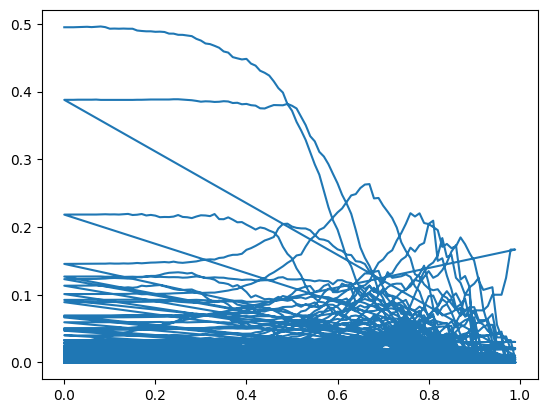

In [ ]:
# plot thres
thres, ious = zip(*perf_thres)
plt.plot(thres, ious)
plt.show()

### GRAM

In [ ]:
with open(GRAM_GT_TRAIN, "r") as f:
    gt_queries_videos_train_gram = json.load(f)
queries = gt_queries_videos_train_gram.keys()
sim_matrix_train_df = pd.read_csv(GRAM_SIM_TRAIN).set_index("video_id")
gram_norm_train_df = normalize_per_query(sim_matrix_train_df)
gram_norm_train_df.head()

,An animal engaged in any activity other than foraging.,An animal that is neither a red deer nor a roe deer.,An animal running.,An animal bathing.,A roe deer grazing.,An animal browsing.,An adult roe deer sniffing.,A juvenile red deer scratching its body.,A chamois trotting.,An adult male roe deer jumping.,...,An animal looking at a camera.,A wolf reacting to a camera.,An animal reacting to a camera and then foraging.,"An animal foraging, then reacting to a camera, and then returning to foraging.",An animal reacting to a camera and then running away.,"An animal foraging, then reacting to a camera, and then running away.",An animal reacting to a camera in rainy or overcast weather.,An animal reacting to a camera in clear or sunny weather.,A single adult red deer foraging only.,An empty video.
video_id,,,,,,,,,,,,,,,,,,,,,
S1_C1_E104_V0262,0.562562,0.658477,0.334305,0.258028,0.785109,0.561407,0.813291,0.784632,0.293086,0.694007,...,0.500918,0.517805,0.705216,0.732896,0.562628,0.712369,0.560909,0.489789,0.800702,0.609574
S1_C1_E104_V0263,0.546555,0.667709,0.321458,0.257880,0.765121,0.557252,0.789779,0.766330,0.324182,0.678777,...,0.488758,0.480969,0.670732,0.693347,0.528861,0.664672,0.537853,0.471507,0.784838,0.628724
S1_C1_E104_V0264,0.583352,0.682183,0.366623,0.313302,0.786195,0.562415,0.804125,0.792180,0.336817,0.682971,...,0.506028,0.502114,0.694851,0.729424,0.576753,0.711325,0.551500,0.486424,0.816633,0.535642
S1_C1_E104_V0265,0.557534,0.683094,0.416944,0.296272,0.835102,0.587794,0.837613,0.827049,0.367367,0.724043,...,0.545354,0.509213,0.680191,0.706887,0.568428,0.701801,0.547952,0.477736,0.825581,0.523153
S1_C1_E104_V0266,0.542293,0.657057,0.414769,0.322216,0.821934,0.566112,0.818956,0.824803,0.324131,0.721363,...,0.524547,0.517326,0.673610,0.696443,0.598235,0.708037,0.542151,0.483804,0.814609,0.525951


In [ ]:
thrs = np.arange(gram_norm_train_df.values.min(), gram_norm_train_df.values.max(), step=step_cste)
best_t_gram = dict.fromkeys(gt_queries_videos_train_gram.keys())
for q in gt_queries_videos_train_gram.keys():
    best_IoU = 0
    if q not in gram_norm_train_df.columns:
        print(f"Query {q} has not been processed")
        continue
    gt_videos_q = list(gt_queries_videos_train_gram[q]["videos"])
    for t in thrs:
        ass_videos_q = list(gram_norm_train_df.index[gram_norm_train_df[q] > t])
        iou = IoU_q(gt_videos_q, ass_videos_q)
        if not np.isnan(iou) and iou > best_IoU:
            best_IoU = iou
            best_t_gram[q] = t
    
    if best_t_gram[q] is None:
        print(f"No best threshold found for {q}, using median similarity score as threshold")
        best_t_gram[q] = np.min(gram_norm_train_df.values)

Query A juvenile roe deer preparing to suckle. has not been processed
Query A fox chasing prey. has not been processed
Query A juvenile red deer shaking its head or body. has not been processed
Query A red deer vocalizing in rainy weather. has not been processed
Query A red deer participating in courtship in rainy weather. has not been processed
Query A video of three or more adult male red deer walking while foraging. has not been processed
Query A video of two or more wolves. has not been processed
Query A juvenile roe deer suckling. has not been processed
Query A wolf chasing prey in overcast or rainy weather. has not been processed
Query A fox chasing prey in clear weather. has not been processed
Query An adult female red deer escaping in sunny weather. has not been processed
Query A video of three or more red deer reacting to a camera. has not been processed
Query A fox reacting to a camera. has not been processed


In [ ]:
mF1_gram, F1_queries_gram = F1_score_from_sim(gt_queries_videos=gt_queries_videos_train_gram, sim_matrix_df=gram_norm_train_df, best_thresholds=best_t_gram)
mIoU_gram, IoU_queries_gram = IoU_from_sim(gt_queries_videos=gt_queries_videos_train_gram, sim_matrix_df=gram_norm_train_df, best_thresholds=best_t_gram)

Query A juvenile roe deer preparing to suckle. has not been processed
Query A fox chasing prey. has not been processed
Query A juvenile red deer shaking its head or body. has not been processed
Query A red deer vocalizing in rainy weather. has not been processed
Query A red deer participating in courtship in rainy weather. has not been processed
Query A video of three or more adult male red deer walking while foraging. has not been processed
Query A video of two or more wolves. has not been processed
Query A juvenile roe deer suckling. has not been processed
Query A wolf chasing prey in overcast or rainy weather. has not been processed
Query A fox chasing prey in clear weather. has not been processed
Query An adult female red deer escaping in sunny weather. has not been processed
Query A video of three or more red deer reacting to a camera. has not been processed
Query A fox reacting to a camera. has not been processed
Query A juvenile roe deer preparing to suckle. has not been process

In [ ]:
print(f"F1-score (macro-avg.): {mF1_gram:.3f}")
print(f"mean IoU: {mIoU_gram:.3f}")

F1-score (macro-avg.): 0.091
mean IoU: 0.051


## Evaluate on Test Split (Thresholds Calibrated on Train)

The per-query thresholds found above are now applied to the **held-out test split**.
This is the only number that should appear in the paper.

In [ ]:
# Apply calibrated thresholds to the normalized TEST similarity matrices
mF1_clip_test, F1_queries_clip_test = F1_score_from_sim(
    gt_queries_videos=clip_gt,
    sim_matrix_df=clip_norm_df,       # test, normalized
    best_thresholds=best_t_clip,
)
mIoU_clip_test, IoU_queries_clip_test = IoU_from_sim(
    gt_queries_videos=clip_gt,
    sim_matrix_df=clip_norm_df,
    best_thresholds=best_t_clip,
)

mF1_gram_test, F1_queries_gram_test = F1_score_from_sim(
    gt_queries_videos=gram_gt,
    sim_matrix_df=gram_norm_df,       # test, normalized
    best_thresholds=best_t_gram,
)
mIoU_gram_test, IoU_queries_gram_test = IoU_from_sim(
    gt_queries_videos=gram_gt,
    sim_matrix_df=gram_norm_df,
    best_thresholds=best_t_gram,
)

print("Test performance (thresholds from train):")
print(f"  CLIP4Clip  F1={mF1_clip_test:.3f}  mIoU={mIoU_clip_test:.3f}  mAP={mAP_clip:.3f}")
print(f"  GRAM       F1={mF1_gram_test:.3f}  mIoU={mIoU_gram_test:.3f}  mAP={mAP_gram:.3f}")

Query A juvenile roe deer preparing to suckle. has not been processed
Query A fox sniffing. has not been processed
Query A fox chasing prey. has not been processed
Query A juvenile red deer shaking its head or body. has not been processed
Query A juvenile roe deer. has not been processed
Query A video of two adult red deer vocalizing while participating in courtship. has not been processed
Query A roe deer participating in courtship in rainy weather. has not been processed
Query A video of three or more adult male red deer walking while foraging. has not been processed
Query A juvenile roe deer suckling. has not been processed
Query A fox chasing prey in clear weather. has not been processed
Query An adult female red deer escaping in sunny weather. has not been processed
Query A fox reacting to a camera. has not been processed
Query A wolf reacting to a camera. has not been processed
Query A juvenile roe deer preparing to suckle. has not been processed
Query A fox sniffing. has not bee

## Summary Table

In [ ]:
best_t_gram

{'An animal engaged in any activity other than foraging.': np.float64(0.02),
 'An animal that is neither a red deer nor a roe deer.': np.float64(0.08),
 'An animal running.': np.float64(0.0),
 'An animal bathing.': np.float64(0.44),
 'A roe deer grazing.': np.float64(0.86),
 'An animal browsing.': np.float64(0.74),
 'An adult roe deer sniffing.': np.float64(0.85),
 'A juvenile red deer scratching its body.': np.float64(0.93),
 'A juvenile roe deer preparing to suckle.': None,
 'A chamois trotting.': np.float64(0.45),
 'An adult male roe deer jumping.': np.float64(0.16),
 'An adult male red deer rubbing its antlers on the ground.': np.float64(0.77),
 'A fox sniffing.': np.float64(0.84),
 'A fox chasing prey.': None,
 'A wolf chasing prey.': np.float64(0.5700000000000001),
 'A hare.': np.float64(0.11),
 'A marten.': np.float64(0.24),
 'A juvenile red deer playing.': np.float64(0.9),
 'An adult red deer browsing.': np.float64(0.77),
 'A hare foraging.': np.float64(0.1),
 'A chamois.': np.

In [ ]:
def aggregate(df: pd.DataFrame) -> dict:
    """Compute mIoU, macro F1, and mAP from per-query results."""
    return {
        "mIoU":       df["iou"].mean(),
        "F1 (macro)": df["f1"].mean(),
        "mAP":        df["ap"].mean(skipna=True),
    }

# Build per-query results DataFrames from TEST split
clip_results = pd.DataFrame({
    "query":     list(F1_queries_clip_test.keys()),
    "iou":       list(IoU_queries_clip_test.values()),
    "f1":        list(F1_queries_clip_test.values()),
    "ap":        [APs_clip.get(q, np.nan) for q in F1_queries_clip_test.keys()],
    "threshold": [best_t_clip.get(q, np.nan) for q in F1_queries_clip_test.keys()],
}).set_index("query")

gram_results = pd.DataFrame({
    "query":     list(F1_queries_gram_test.keys()),
    "iou":       list(IoU_queries_gram_test.values()),
    "f1":        list(F1_queries_gram_test.values()),
    "ap":        [APs_gram.get(q, np.nan) for q in F1_queries_gram_test.keys()],
    "threshold": [best_t_gram.get(q, np.nan) for q in F1_queries_gram_test.keys()],
}).set_index("query")

clip_agg = aggregate(clip_results)
gram_agg = aggregate(gram_results)

summary_df = pd.DataFrame(
    [clip_agg, gram_agg],
    index=["CLIP4Clip (zero-shot)", "GRAM (zero-shot)"]
)

print("=" * 55)
print("  End-to-end TVR Performance on MammAlps Test Split")
print("=" * 55)
display(
    summary_df.style
    .format("{:.3f}")
    .set_caption("zero-shot evaluation  |  threshold calibrated on train split, evaluated on test split")
)

# LaTeX row for the paper
for model, row in summary_df.iterrows():
    print(f"{model:40s} & {row['mIoU']:.2f} & {row['F1 (macro)']:.2f} & {row['mAP']:.2f} \\\\")

  End-to-end TVR Performance on MammAlps Test Split


,mIoU,F1 (macro),mAP
CLIP4Clip (zero-shot),0.046,0.078,0.086
GRAM (zero-shot),0.023,0.041,0.060


CLIP4Clip (zero-shot)                    & 0.05 & 0.08 & 0.09 \\
GRAM (zero-shot)                         & 0.02 & 0.04 & 0.06 \\


In [ ]:
clip_results.loc["An animal engaged in any activity other than foraging.",:]

iou          0.404092
f1           0.575592
ap           0.562997
threshold    0.080000
Name: An animal engaged in any activity other than foraging., dtype: float64

In [ ]:
# Add category from the TEST ground-truth (same queries as test results)
for query, val in clip_gt.items():
    category = val["category"]
    if query in clip_results.index:
        clip_results.loc[query, "category"] = category

for query, val in gram_gt.items():
    category = val["category"]
    if query in gram_results.index:
        gram_results.loc[query, "category"] = category

In [ ]:
clip_results

,iou,f1,ap,threshold,category
query,,,,,
An animal engaged in any activity other than foraging.,0.404092,0.575592,0.562997,0.08,RARE
An animal that is neither a red deer nor a roe deer.,0.025940,0.050569,0.016045,0.11,RARE
An animal running.,0.119298,0.213166,0.180409,0.49,RARE
An animal bathing.,0.000000,0.000000,0.087593,0.81,RARE
A roe deer grazing.,0.000000,0.000000,0.010787,0.83,RARE
...,...,...,...,...,...
"An animal foraging, then reacting to a camera, and then running away.",0.006309,0.012539,0.035645,0.75,CAMERA_REACTION
An animal reacting to a camera in rainy or overcast weather.,0.040000,0.076923,0.195017,0.67,CAMERA_REACTION
An animal reacting to a camera in clear or sunny weather.,0.042802,0.082090,0.075917,0.29,CAMERA_REACTION


## Breakdown by Category (RARE / COMMON)

In [ ]:
rows = []
for model_name, df in [("CLIP4Clip", clip_results), ("GRAM", gram_results)]:
    display(df.head(3))
    for cat, sub in df.groupby("category"):
        a = aggregate(sub)
        rows.append({"Model": model_name, "Category": cat, **a, "n_queries": len(sub)})

cat_df = pd.DataFrame(rows).set_index(["Model", "Category"])
display(cat_df.style.format({"mIoU": "{:.3f}", "F1 (macro)": "{:.3f}", "mAP": "{:.3f}", "n_queries": "{:.0f}"}))

,iou,f1,ap,threshold,category
query,,,,,
An animal engaged in any activity other than foraging.,0.404092,0.575592,0.562997,0.08,RARE
An animal that is neither a red deer nor a roe deer.,0.025940,0.050569,0.016045,0.11,RARE
An animal running.,0.119298,0.213166,0.180409,0.49,RARE


,iou,f1,ap,threshold,category
query,,,,,
An animal engaged in any activity other than foraging.,0.204724,0.339869,0.209645,0.02,RARE
An animal that is neither a red deer nor a roe deer.,0.026954,0.052493,0.015228,0.08,RARE
An animal running.,0.067602,0.126643,0.065442,0.00,RARE


## Threshold Analysis Across Queries

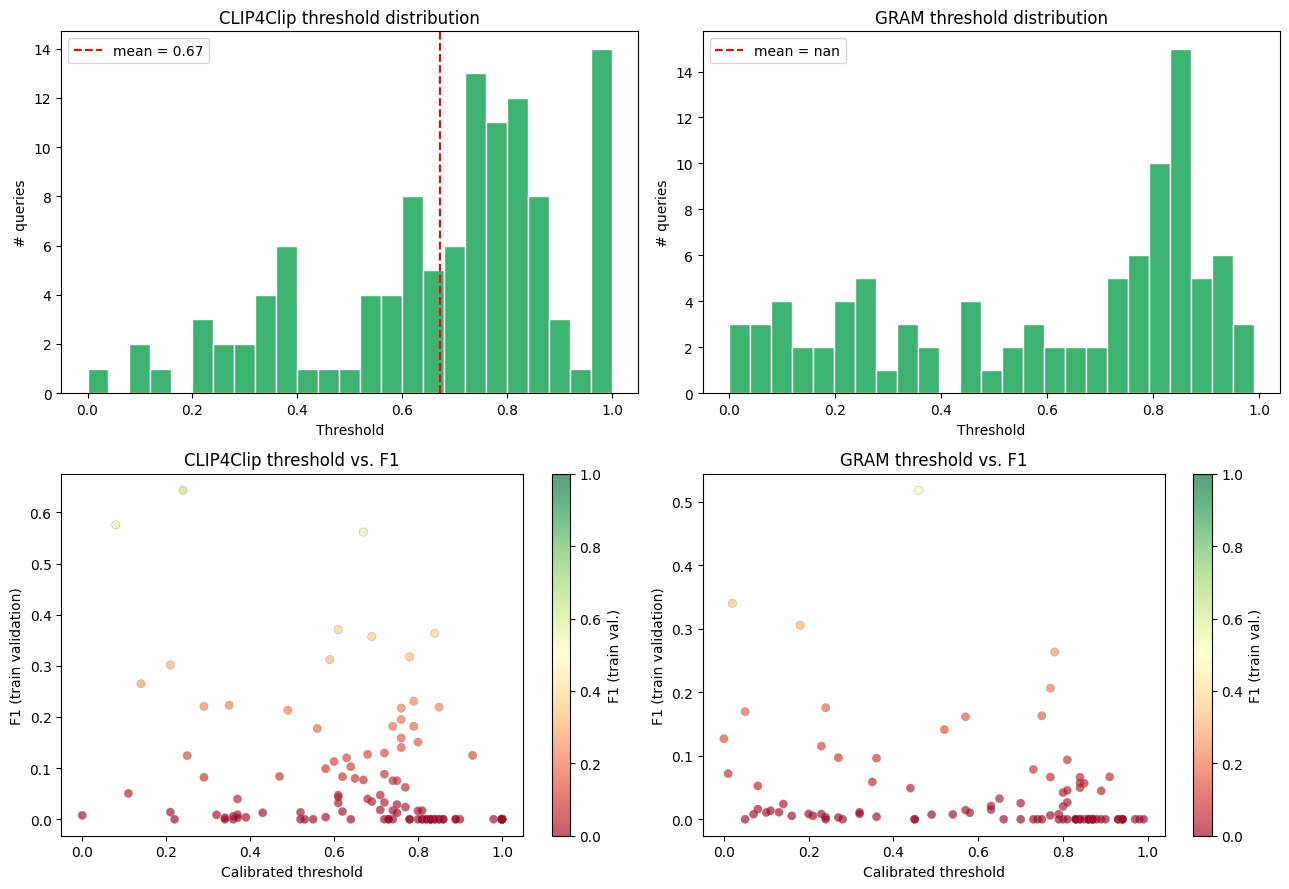

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for col, (res_df, model_name) in enumerate([(clip_results, "CLIP4Clip"), (gram_results, "GRAM")]):
    thresholds = res_df["threshold"].values
    f1s        = res_df["f1"].values

    # Threshold distribution
    ax_hist = axes[0, col]
    ax_hist.hist(thresholds, bins=25, color="mediumseagreen", edgecolor="white")
    ax_hist.axvline(thresholds.mean(), color="red", linewidth=1.5, linestyle="--",
                    label=f"mean = {thresholds.mean():.2f}")
    ax_hist.set_title(f"{model_name} threshold distribution")
    ax_hist.set_xlabel("Threshold")
    ax_hist.set_ylabel("# queries")
    ax_hist.legend()

    # Threshold vs F1 scatter
    ax_scat = axes[1, col]
    sc = ax_scat.scatter(thresholds, f1s, c=f1s, cmap="RdYlGn", vmin=0, vmax=1,
                         alpha=0.65, edgecolors="grey", linewidths=0.3)
    plt.colorbar(sc, ax=ax_scat, label="F1 (train val.)")
    ax_scat.set_title(f"{model_name} threshold vs. F1")
    ax_scat.set_xlabel("Calibrated threshold")
    ax_scat.set_ylabel("F1 (train validation)")

plt.tight_layout()
plt.show()

## Per-Query Breakdown Table

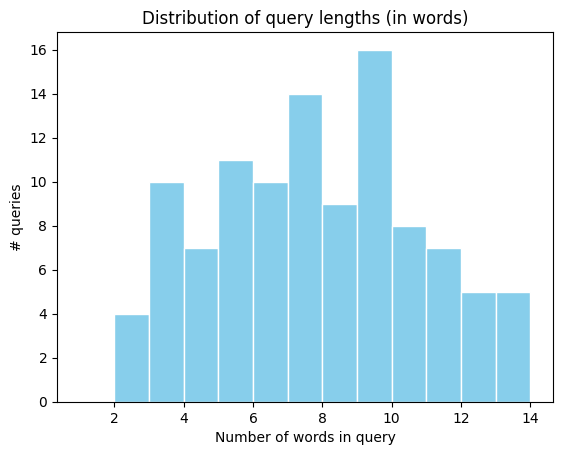

In [ ]:
clip_results.index.to_list()
# histogram of count of words in queries
df_queries = pd.DataFrame({"query": clip_results.index})
df_queries["n_words"] = df_queries["query"].apply(lambda x: len(x.split()))
plt.hist(df_queries["n_words"], bins=range(1, 15), color="skyblue", edgecolor="white")
plt.title("Distribution of query lengths (in words)")
plt.xlabel("Number of words in query")
plt.ylabel("# queries")
plt.show()


In [ ]:
# Merge per-query results from both models
merged = clip_results[["category", "threshold", "f1", "iou", "ap"]].copy()
merged = merged.rename(columns={"threshold": "thr_clip", "f1": "f1_clip", "iou": "iou_clip", "ap": "ap_clip"})

gram_cols = gram_results[["threshold", "f1", "iou", "ap"]].rename(
    columns={"threshold": "thr_gram", "f1": "f1_gram", "iou": "iou_gram", "ap": "ap_gram"}
)
# merged on index since query is the index of both dfs, and they have the same queries as index
merged = merged.merge(gram_cols,
    left_index=True, right_index=True, how="outer"
)

# Flag queries where the gap in F1 exceeds 0.1
merged["f1_diff"] = merged["f1_clip"] - merged["f1_gram"]
merged = merged.sort_values("f1_diff", ascending=False)

merged

,category,thr_clip,f1_clip,iou_clip,ap_clip,thr_gram,f1_gram,iou_gram,ap_gram,f1_diff
query,,,,,,,,,,
An animal being vigilant while the weather is rainy or overcast.,SOCIAL,0.67,0.561404,0.390244,0.583434,0.27,0.097015,0.050980,0.038405,0.464389
A video of two or more juvenile red deer.,SOCIAL,0.84,0.363636,0.222222,0.165648,0.94,0.000000,0.000000,0.004244,0.363636
A video of an animal drinking.,RARE,0.78,0.317460,0.188679,0.157009,0.79,0.000000,0.000000,0.010505,0.317460
An adult red deer vocalizing while participating in courtship.,COURTSHIP,0.61,0.370861,0.227642,0.288607,0.85,0.056604,0.029126,0.056735,0.314257
An adult red deer standing with its head up while participating in courtship.,COURTSHIP,0.69,0.357143,0.217391,0.297179,0.84,0.066225,0.034247,0.057974,0.290918
...,...,...,...,...,...,...,...,...,...,...
A roe deer participating in courtship in rainy weather.,COURTSHIP,0.22,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
A video of three or more adult male red deer walking while foraging.,SOCIAL,1.00,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
A video of two adult red deer vocalizing while participating in courtship.,COURTSHIP,0.55,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
merged[merged["f1_clip"] < 0.1].sort_values("f1_clip", ascending=False).groupby("category").mean(numeric_only=True) # mean per category

,thr_clip,f1_clip,iou_clip,ap_clip,thr_gram,f1_gram,iou_gram,ap_gram,f1_diff
category,,,,,,,,,
CAMERA_REACTION,0.735294,0.033487,0.017319,0.071879,0.824286,0.015048,0.007712,0.047898,0.022904
COMMON,0.470000,0.083721,0.043689,0.050257,0.700000,0.000000,0.000000,0.011671,0.083721
COURTSHIP,0.692308,0.007788,0.004027,0.027400,0.668889,0.000000,0.000000,NaN,0.009204
RARE,0.664545,0.013977,0.007187,0.019638,0.454286,0.021173,0.011137,0.030413,-0.004700
SOCIAL,0.741579,0.010154,0.005192,0.021597,0.623846,0.020329,0.011019,0.034776,-0.007467


In [ ]:
merged[merged['category']=="COMMON"]

,category,thr_clip,f1_clip,iou_clip,ap_clip,thr_gram,f1_gram,iou_gram,ap_gram,f1_diff
query,,,,,,,,,,
A single adult red deer foraging only.,COMMON,0.24,0.643172,0.474026,0.387927,0.46,0.517672,0.349229,0.450438,0.125500
An empty video.,COMMON,0.47,0.083721,0.043689,0.050257,0.70,0.000000,0.000000,0.011671,0.083721


In [ ]:
merged_short = merged[merged.index.to_series().apply(lambda x: len(x.split())) < 10].copy()
merged_short["n_words"] = merged_short.index.to_series().apply(lambda x: len(x.split()))
merged_short.groupby("category").mean(numeric_only=True)

,thr_clip,f1_clip,iou_clip,ap_clip,thr_gram,f1_gram,iou_gram,ap_gram,f1_diff,n_words
category,,,,,,,,,,
CAMERA_REACTION,0.737500,0.048734,0.025539,0.080540,0.834000,0.017914,0.009165,0.047349,0.040567,7.500000
COMMON,0.355000,0.363446,0.258858,0.219092,0.580000,0.258836,0.174614,0.231054,0.104611,5.000000
COURTSHIP,0.660000,0.102363,0.060748,0.105102,0.666667,0.016738,0.008569,0.048775,0.098421,8.111111
RARE,0.642821,0.058652,0.034796,0.067797,0.461471,0.041975,0.023481,0.051414,0.025302,4.743590
SOCIAL,0.693684,0.081323,0.046067,0.085005,0.647143,0.034443,0.018422,0.045897,0.062128,7.210526


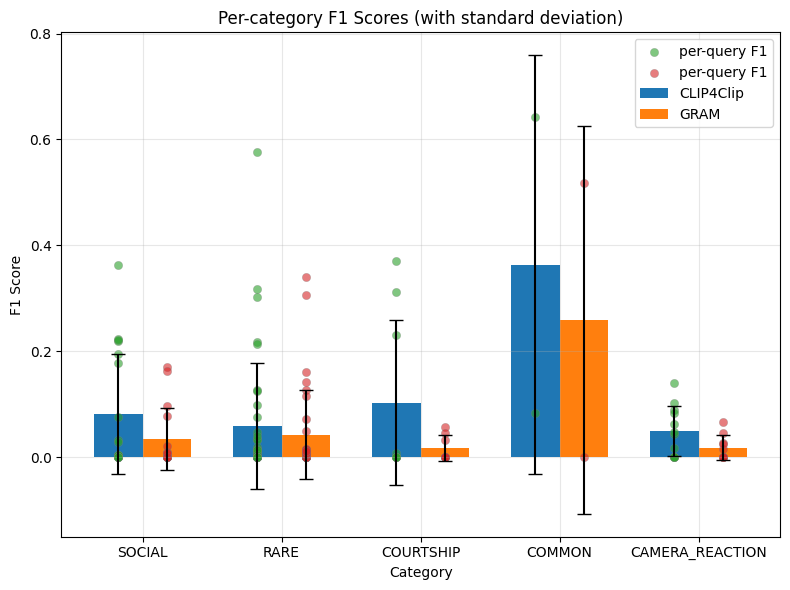

In [ ]:
# barplot per category 2 barplots one for clip and one for gram, x axis category, y axis F1, error bars for stddev across queries in that category
categories = merged_short["category"].fillna("UNKNOWN").unique()
f1_clip_means = []
f1_gram_means = []
f1_clip_stds = []
f1_gram_stds = []

for cat in categories:
    subset = merged_short[merged_short["category"] == cat]
    f1_clip_means.append(subset["f1_clip"].mean())
    f1_gram_means.append(subset["f1_gram"].mean())
    f1_clip_stds.append(subset["f1_clip"].std())
    f1_gram_stds.append(subset["f1_gram"].std())

x_pos = range(len(categories))
width = 0.35

plt.figure(figsize=(8, 6))
bars_clip = plt.bar([x - width/2 for x in x_pos], f1_clip_means, width, label="CLIP4Clip", yerr=f1_clip_stds, capsize=5)
bars_gram = plt.bar([x + width/2 for x in x_pos], f1_gram_means, width, label="GRAM", yerr=f1_gram_stds, capsize=5)
scatter_clip_per_query_per_category = plt.scatter(
    [x_pos[categories.tolist().index(cat)] - width/2 for cat in merged_short["category"].fillna("UNKNOWN")],
    merged_short["f1_clip"],
    alpha=0.6, edgecolors="grey", linewidths=0.3, label="per-query F1"
)

scatter_gram_per_query_per_category = plt.scatter(
    [x_pos[categories.tolist().index(cat)] + width/2 for cat in merged_short["category"].fillna("UNKNOWN")],
    merged_short["f1_gram"],
    alpha=0.6, edgecolors="grey", linewidths=0.3, label="per-query F1"
)
plt.xlabel("Category")
plt.ylabel("F1 Score")
plt.title("Per-category F1 Scores (with standard deviation)")
plt.xticks(x_pos, categories)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

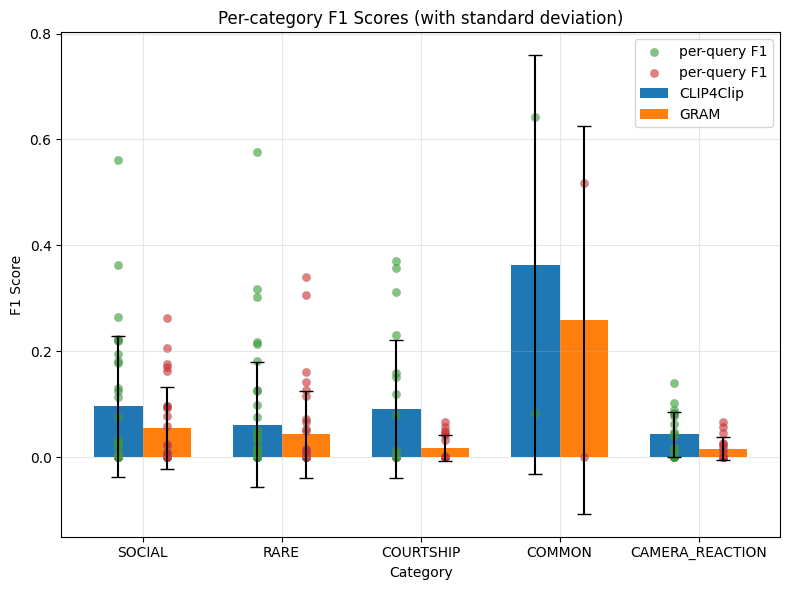

In [ ]:
# barplot per category 2 barplots one for clip and one for gram, x axis category, y axis F1, error bars for stddev across queries in that category
categories = merged["category"].fillna("UNKNOWN").unique()
f1_clip_means = []
f1_gram_means = []
f1_clip_stds = []
f1_gram_stds = []

for cat in categories:
    subset = merged[merged["category"] == cat]
    f1_clip_means.append(subset["f1_clip"].mean())
    f1_gram_means.append(subset["f1_gram"].mean())
    f1_clip_stds.append(subset["f1_clip"].std())
    f1_gram_stds.append(subset["f1_gram"].std())

x_pos = range(len(categories))
width = 0.35

plt.figure(figsize=(8, 6))
bars_clip = plt.bar([x - width/2 for x in x_pos], f1_clip_means, width, label="CLIP4Clip", yerr=f1_clip_stds, capsize=5)
bars_gram = plt.bar([x + width/2 for x in x_pos], f1_gram_means, width, label="GRAM", yerr=f1_gram_stds, capsize=5)
scatter_clip_per_query_per_category = plt.scatter(
    [x_pos[categories.tolist().index(cat)] - width/2 for cat in merged["category"].fillna("UNKNOWN")],
    merged["f1_clip"],
    alpha=0.6, edgecolors="grey", linewidths=0.3, label="per-query F1"
)

scatter_gram_per_query_per_category = plt.scatter(
    [x_pos[categories.tolist().index(cat)] + width/2 for cat in merged["category"].fillna("UNKNOWN")],
    merged["f1_gram"],
    alpha=0.6, edgecolors="grey", linewidths=0.3, label="per-query F1"
)
plt.xlabel("Category")
plt.ylabel("F1 Score")
plt.title("Per-category F1 Scores (with standard deviation)")
plt.xticks(x_pos, categories)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
merged[merged["category"] == "SOCIAL"]

,category,thr_clip,f1_clip,iou_clip,ap_clip,thr_gram,f1_gram,iou_gram,ap_gram,f1_diff
query,,,,,,,,,,
An animal being vigilant while the weather is rainy or overcast.,SOCIAL,0.67,0.561404,0.390244,0.583434,0.27,0.097015,0.050980,0.038405,0.464389
A video of two or more juvenile red deer.,SOCIAL,0.84,0.363636,0.222222,0.165648,0.94,0.000000,0.000000,0.004244,0.363636
A video of three or more red deer.,SOCIAL,0.85,0.219178,0.123077,0.227174,0.80,0.020202,0.010204,0.018288,0.198976
"Two or more red deer foraging, with at least one also being vigilant at some point.",SOCIAL,0.79,0.181818,0.100000,0.076110,0.87,0.000000,0.000000,0.016838,0.181818
A red deer foraging in rainy weather.,SOCIAL,0.35,0.222930,0.125448,0.228301,0.36,0.096128,0.050491,0.103935,0.126802
A red deer foraging in sunny weather.,SOCIAL,0.76,0.195122,0.108108,0.228330,0.73,0.078431,0.040816,0.048247,0.116691
A video of two adult female red deer walking while foraging.,SOCIAL,0.93,0.125000,0.066667,0.131119,0.14,0.024000,0.012146,0.008131,0.101000
An animal being vigilant while the weather is clear or sunny.,SOCIAL,0.14,0.265060,0.152778,0.185707,0.24,0.175563,0.096229,0.103305,0.089497
A juvenile red deer walking while being vigilant.,SOCIAL,0.75,0.075472,0.039216,0.023243,0.87,0.000000,0.000000,0.001859,0.075472


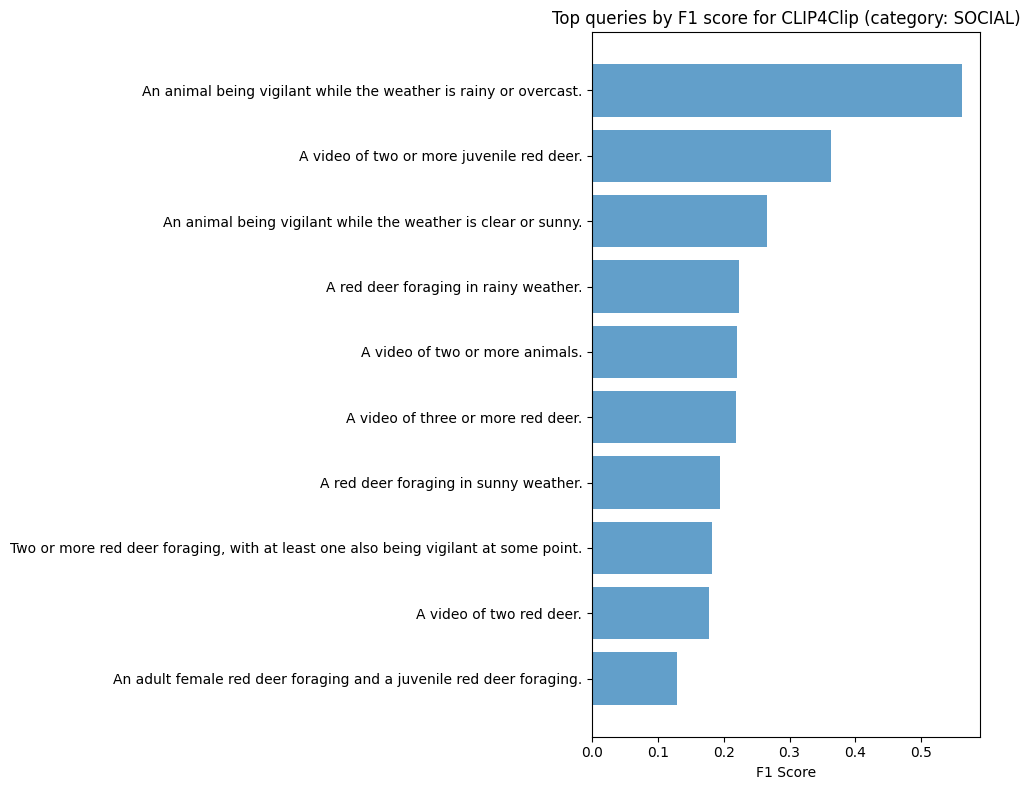

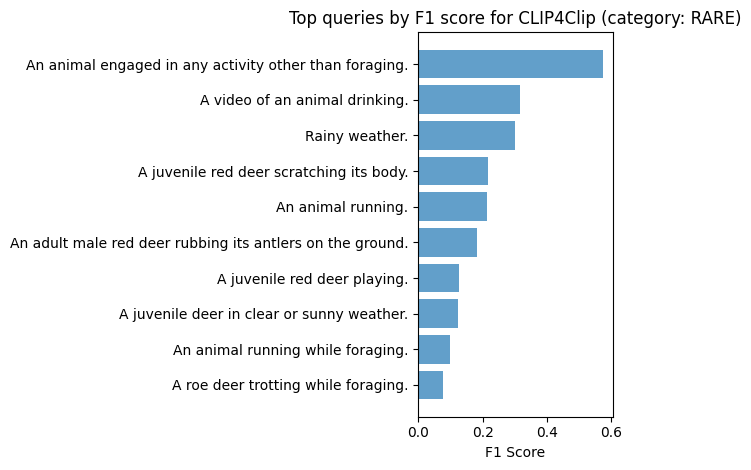

/tmp/ipykernel_963496/1315215639.py:12: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


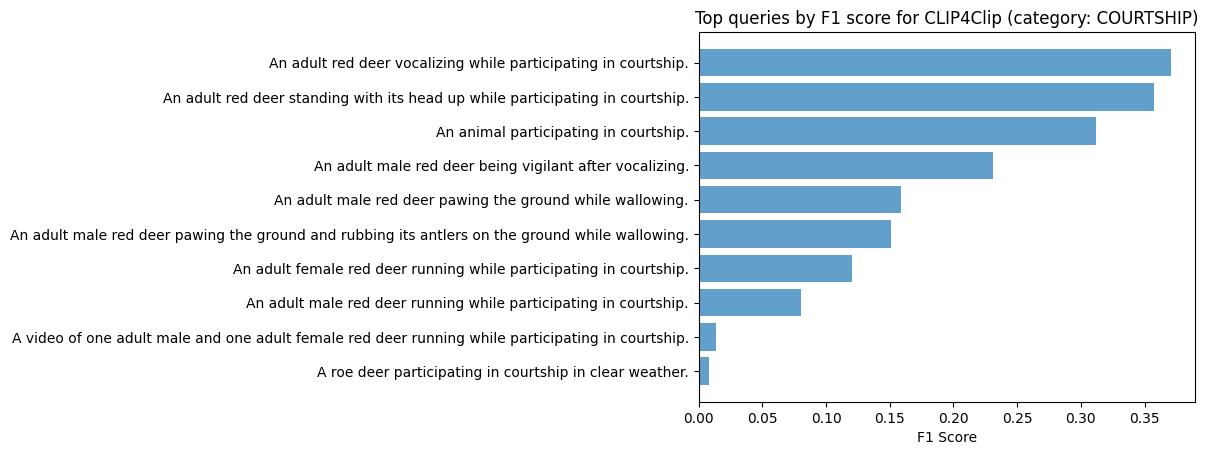

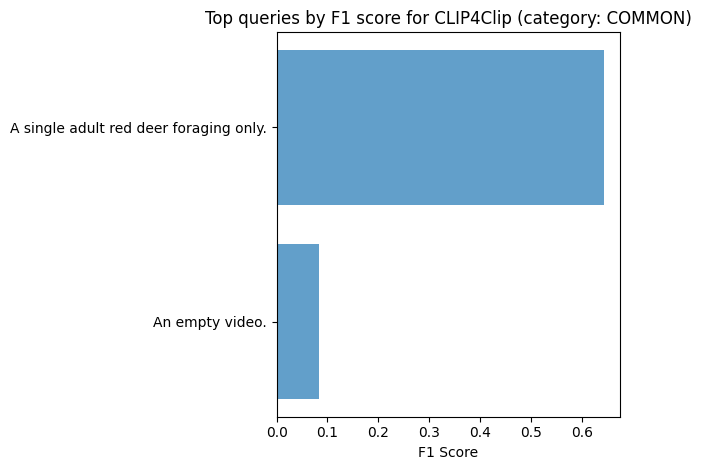

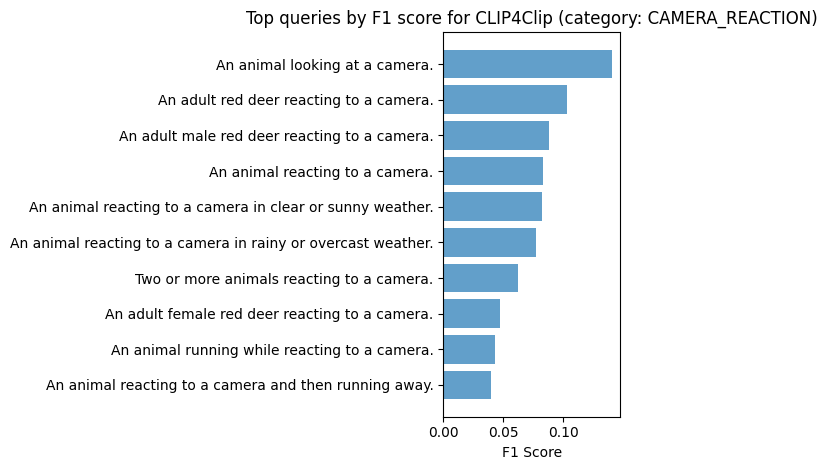

In [ ]:
# plot horizantal barplot top query per category with highest F1 5 plots, that shows the top 10 queries with the highest f1 score
categories = merged["category"].unique()
plt.figure(figsize=(10, 8))
for i, cat in enumerate(categories):
    subset = merged[merged["category"] == cat]
    subset_top10 = subset.sort_values("f1_clip", ascending=False).head(10)
    # highest f1 at the top, so sort by f1_clip ascending and use barh
    subset_top10 = subset_top10.sort_values("f1_clip", ascending=True)
    plt.barh(subset_top10.index, subset_top10["f1_clip"], label=f"{cat} (CLIP4Clip)", alpha=0.7)
    plt.xlabel("F1 Score")
    plt.title(f"Top queries by F1 score for CLIP4Clip (category: {cat})")
    plt.tight_layout()
    plt.show()

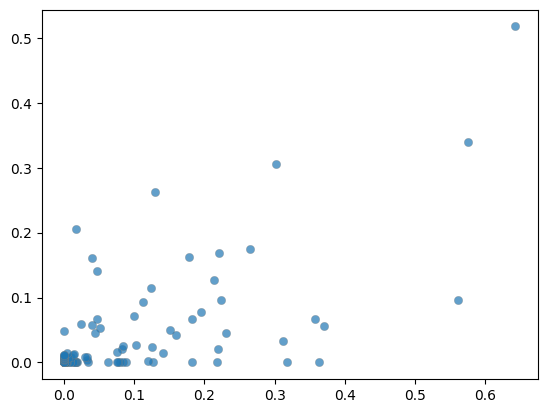

In [ ]:
plt.scatter(merged["f1_clip"], merged["f1_gram"], alpha=0.7, edgecolors="grey", linewidths=0.3)

In [ ]:
OUT_DIR = Path("results")
OUT_DIR.mkdir(exist_ok=True)

clip_results.to_csv(OUT_DIR / "clip4clip_test_per_query.csv", index=False)
gram_results.to_csv(OUT_DIR / "gram_test_per_query.csv", index=False)
merged.to_csv(OUT_DIR / "comparison_per_query.csv", index=False)

summary_df.to_csv(OUT_DIR / "summary_table.csv")

print("Saved:")
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f}")

Saved:
  results/clip4clip_test_per_query.csv
  results/comparison_per_query.csv
  results/gram_test_per_query.csv
  results/summary_table.csv
